In [1]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

In [2]:
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
from kszcnn.simplified_cnn_err_density import *

In [4]:
np.random.seed(SEED)
torch.manual_seed(SEED)

In [5]:
#  1. Load grids
grid_train, grid_test = memmap_grid_slices(
    GRID_FILE, [TRAIN_REAL_IDX, TEST_REAL_IDX]
)

print("Grid shapes:", grid_train.shape, grid_test.shape)

Grid shapes: (128, 128, 128) (128, 128, 128)


In [6]:
# 2. Smooth density
delta_train = smooth_density_kspace(grid_train, SMOOTH_SCALE)
delta_test  = smooth_density_kspace(grid_test, SMOOTH_SCALE)

In [7]:
#  3. Normalize
mean = delta_train.mean()
std  = delta_train.std() + 1e-12

delta_train = (delta_train - mean) / std
delta_test  = (delta_test - mean) / std

In [8]:
# 4. Load halos
pos_tr, vel_tr, mass_tr = load_halos(TRAIN_HALO_FILE)
pos_te, vel_te, mass_te = load_halos(TEST_HALO_FILE)

pos_tr = redshift_err(pos_tr, sigma_z=0.1)
pos_te = redshift_err(pos_te, sigma_z=0.1)


print("Halos:", len(pos_tr), len(pos_te))

Halos: 20817 21205


In [9]:
#  5. Dataset 
rng = np.random.RandomState(SEED)
train_ds_full = HaloDataset(
    delta_train,
    pos_tr,
    vel_tr,
    mass_tr,
    mass_cut=MASS_CUT, max_n=MAX_HALOS,
    rng=rng
)

test_ds = HaloDataset(
    delta_test,
    pos_te,
    vel_te,
    mass_te,
    mass_cut=MASS_CUT, max_n=MAX_HALOS,
    rng=rng
)

Selected halos: 547
Selected halos: 569


In [10]:
#  6. Linear baseline 
vlin_test = compute_vlin_from_density(
    grid_test,R_smooth=SMOOTH_SCALE
)

vlin_baseline = vlin_at_halos(vlin_test, test_ds.pos)

rho_vlin = pearsonr(test_ds.vz, vlin_baseline)[0]

print("Linear theory correlation:", rho_vlin)

Linear theory correlation: -0.07529198


In [11]:
#7. Train / validation
idxs = np.arange(len(train_ds_full))

tr_idx, val_idx = train_test_split(
    idxs,
    test_size=0.2,
    random_state=SEED
)

tr_ds  = Subset(train_ds_full, tr_idx)
val_ds = Subset(train_ds_full, val_idx)

In [12]:
#  8. Loaders
tr_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH)
te_loader  = DataLoader(test_ds, batch_size=BATCH)

In [13]:
#  9. Normalize velocity
y_train = np.array([train_ds_full[i][1] for i in tr_idx])

y_mean = y_train.mean()
y_std  = y_train.std() + 1e-12

print("Velocity mean/std:", y_mean, y_std)

Velocity mean/std: -1.0862699 105.11467


In [14]:
model = CNN().to(DEVICE)

In [15]:
train_model(
        model, tr_loader, val_loader, y_mean, y_std
    )

Epoch 1: Train=4.052e-01 | Val=9.713e-01
Epoch 2: Train=3.908e-01 | Val=9.661e-01
Epoch 3: Train=3.903e-01 | Val=9.668e-01
Epoch 4: Train=3.902e-01 | Val=9.674e-01
Epoch 5: Train=3.877e-01 | Val=9.685e-01
Epoch 6: Train=3.867e-01 | Val=9.733e-01
Epoch 7: Train=3.899e-01 | Val=9.716e-01
Epoch 8: Train=3.860e-01 | Val=9.747e-01
Epoch 9: Train=3.905e-01 | Val=9.740e-01
Epoch 10: Train=3.853e-01 | Val=9.875e-01
Epoch 11: Train=3.864e-01 | Val=9.974e-01
Epoch 12: Train=3.833e-01 | Val=9.814e-01
Epoch 13: Train=3.825e-01 | Val=9.801e-01
Epoch 14: Train=3.816e-01 | Val=9.934e-01
Epoch 15: Train=3.832e-01 | Val=9.908e-01
Epoch 16: Train=3.790e-01 | Val=9.953e-01
Epoch 17: Train=3.819e-01 | Val=1.036e+00
Epoch 18: Train=3.796e-01 | Val=9.842e-01
Epoch 19: Train=3.797e-01 | Val=1.003e+00
Epoch 20: Train=3.787e-01 | Val=1.002e+00
Epoch 21: Train=3.804e-01 | Val=1.004e+00
Epoch 22: Train=3.762e-01 | Val=1.009e+00
Epoch 23: Train=3.697e-01 | Val=1.023e+00
Epoch 24: Train=3.688e-01 | Val=1.016e+00
E

CNN(
  (conv): Sequential(
    (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): GroupNorm(8, 64, eps=1e-05, affine=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): GroupNorm(8, 128, eps=1e-05, affine=True)
    (10): ReLU()
    (11): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool3d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)


===== TEST RESULTS =====
N = 569
RMSE = 97.067
RMS(true) = 96.798
RMS(pred) = 0.795


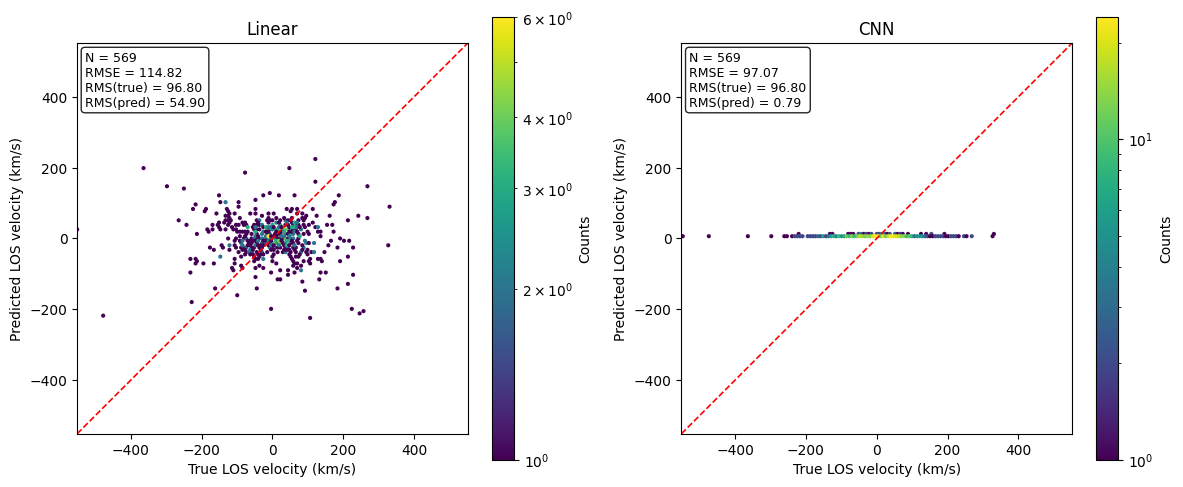

In [16]:
evaluate_model(
        model, te_loader, test_ds,
        y_mean, y_std,
        vlin_baseline, rho_vlin
    )